In [7]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#Load existing dataset from CSV if it exists, otherwise create it from intial data 
#Return both the full dataframe and numpy arrays (x inputs, y outputs)
csv_path = Path("function_7_data.csv")

def load_or_create_dataset():
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        X_init = np.load('../data/initial_data/function_7/initial_inputs.npy')
        y_init = np.load('../data/initial_data/function_7/initial_outputs.npy')

        df = pd.DataFrame(X_init, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])
        df['y'] = y_init
        df.to_csv(csv_path, index=False)

    X = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']].to_numpy()
    y = df['y'].to_numpy()

    return df, X, y

df, X, y = load_or_create_dataset()


#Checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)

Inputs Shape: (43, 6)
Outputs Shape: (43,)


In [9]:
#Append newly observed datapoints to existing CSV to keep a single up to date dataset

#Create a function to do this
def append_bo_result(x_new, y_new):
    df = pd.read_csv(csv_path)
    new_row = pd.DataFrame([[x_new[0], x_new[1], x_new[2], x_new[3], x_new[4], x_new[5], y_new]], columns=df.columns)
    df = pd.concat([df, new_row], ignore_index=True)
    df.to_csv(csv_path, index=False)
    return df

#Adding new values to my CSV df
#x_new = [0.052616, 0.282290, 0.360370, 0.315780, 0.269591, 0.686090]
#y_new = 2.652186251849479

#df = append_bo_result(x_new, y_new)

# Refresh X and y from the updated live dataframe
X = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6']].to_numpy()
y = df['y'].to_numpy()

df.tail()

,x1,x2,x3,x4,x5,x6,y
38,0.060500,0.172597,0.264213,0.326575,0.276599,0.713945,2.654559
39,0.175989,0.121379,0.323001,0.284117,0.217745,0.565364,2.560121
40,0.116511,0.296783,0.304712,0.233135,0.233990,0.560979,2.309503
41,0.161202,0.073905,0.214604,0.308743,0.435244,0.626466,2.141788
42,0.052616,0.282290,0.360370,0.315780,0.269591,0.686090,2.652186


,x1,x2,x3,x4,x5,x6,y
38,0.060500,0.172597,0.264213,0.326575,0.276599,0.713945,2.654559
39,0.175989,0.121379,0.323001,0.284117,0.217745,0.565364,2.560121
40,0.116511,0.296783,0.304712,0.233135,0.233990,0.560979,2.309503
41,0.161202,0.073905,0.214604,0.308743,0.435244,0.626466,2.141788
42,0.052616,0.282290,0.360370,0.315780,0.269591,0.686090,2.652186


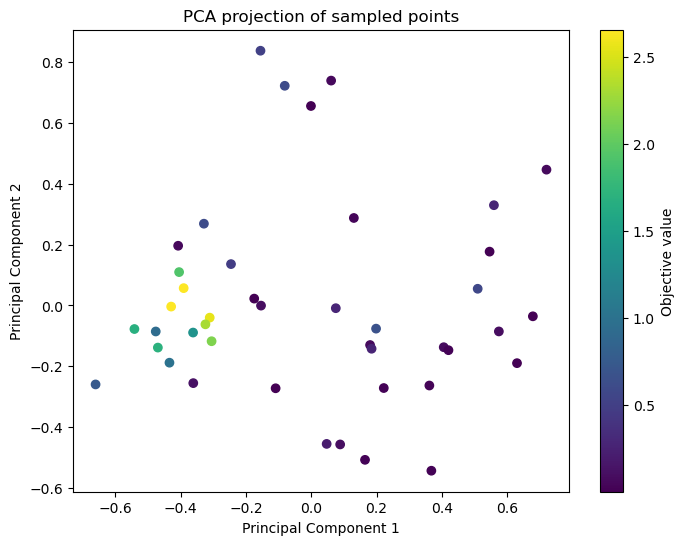

In [11]:
#Create a PCA plot to visulize patterns in the data

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.colorbar(scatter, label="Objective value")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of sampled points")
plt.show()

In [33]:
#Define GP hyperparameters and make a grid / generate random candidate points for acqusition optimisation 

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

#hyperparamters for GP surrogate model and acqusition function 
matern_lengthscale = 0.2
nu = 1.5 
noise_assumption = 0.2
xi = 0.005

#Setting number of random candidate points 
n_candidates = 5000  

# sample uniformly in [0, 1]^6
X_candidates = np.random.rand(n_candidates, 6)


In [35]:
#Fit the GP to the current data 

kernel = (C(1.0, (1e-2, 1e2)) * Matern(length_scale= 0.2, length_scale_bounds=(0.05, 1), nu=1.5) 
    + WhiteKernel(noise_level=0.2, noise_level_bounds=(1e-8, 1)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=8, random_state=0)
gp.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=0.2, nu=1.5) + WhiteKernel(noise_level=0.2),
                         n_restarts_optimizer=8, normalize_y=True,
                         random_state=0)

In [37]:
#Setting up and running acqusition function 

from scipy.stats import norm
import numpy as np

#Expected Improvement  

#Write the function
def expected_improvement(mu, sigma, y_best, xi=0.005):
    sigma = np.maximum(sigma, 1e-12)
    imp = mu - y_best - xi
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

# Predict GP on candidate set
mu, std = gp.predict(X_candidates, return_std=True)

# Best observed so far (maximization)
y_best = float(np.max(y))

# Compute EI and use it to select next point 
ei = expected_improvement(mu, std, y_best, xi=xi)  # use your xi
ix = int(np.argmax(ei))
x_next = X_candidates[ix]
print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f},{x_next[2]:.6f},{x_next[3]:.6f},{x_next[4]:.6f},{x_next[5]:.6f}) ")


# Probability of Improvement (used in final round - see logic sheet)

# Write the function
def probability_of_improvement(mu, sigma, y_best, xi=0.005):
    sigma = np.maximum(sigma, 1e-12)
    Z = (mu - y_best - xi) / sigma
    return norm.cdf(Z)

# Predict GP on candidate set
mu, std = gp.predict(X_candidates, return_std=True)

# Best observed so far (maximization)
y_best = float(np.max(y))

# Compute PI and select next point
pi = probability_of_improvement(mu, std, y_best, xi=xi)  # use your xi
ix = int(np.argmax(pi))
x_next = X_candidates[ix]

print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f}, {x_next[2]:.6f}, "f"{x_next[3]:.6f}, {x_next[4]:.6f}, {x_next[5]:.6f})")

In [39]:
#UCB acqusition used at the start of the optimisation process
#ucb= mu + beta * std
# predict mean + std at candidate points
#mu, sigma = gp.predict(X_candidates, return_std=True)
# choose best candidate
#ix = np.argmax(ucb)
#x_next = X_candidates[ix]
#print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f}, {x_next[2]:.6f}, "f"{x_next[3]:.6f}, {x_next[4]:.6f}, {x_next[5]:.6f})")

x_next = (0.074197, 0.258587,0.228301,0.402572,0.162003,0.549746) 


x_next = (0.074197, 0.258587, 0.228301, 0.402572, 0.162003, 0.549746)


In [58]:
#Setting up an SVM classifier to qualify potential points 
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Top 20% of points are labelled as promising
n_promising = max(3, int(0.20 * len(y)))

# Indices of the top-performing points
top_indices = np.argsort(y)[-n_promising:]

# Create binary labels: 1 = promising, 0 = not promising
labels = np.zeros(len(y), dtype=int)
labels[top_indices] = 1

#Build a classifer which standardises inputs 
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))])

#Fit the data 
svm_clf.fit(X, labels)

train_preds = svm_clf.predict(X)

print("True labels:     ", labels)
print("Predicted labels:", train_preds)


True labels:      [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 1 1 1 1 1]
Predicted labels: [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1
 1 1 1 1 1]


In [60]:
#Use the SVM classifier to predict whether candididate point is in promising region
svm_prediction = svm_clf.predict(x_next.reshape(1, -1))[0]

print("SVM prediction:", svm_prediction)

def is_promising_point(model, x_candidate):
    prediction = model.predict(x_candidate.reshape(1, -1))[0]
    return prediction == 1
if is_promising_point(svm_clf, x_next):
    print("Promising region")
else:
    print("Not promising")

SVM prediction: 1
Promising region


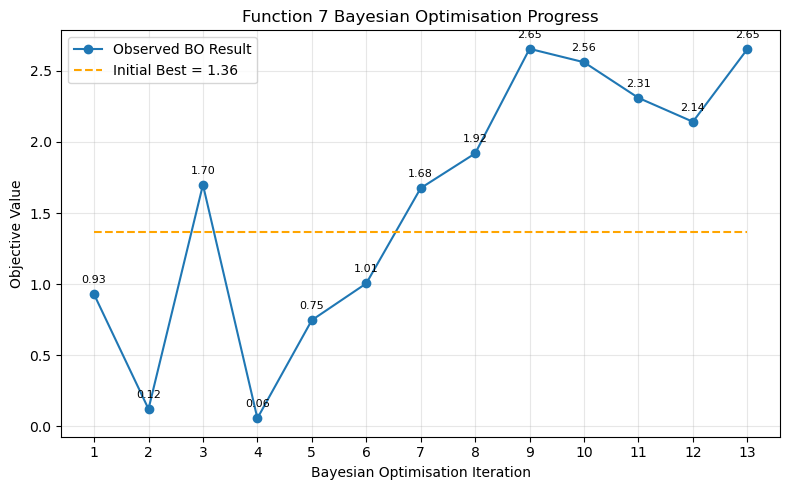

In [13]:
# Plot a graph to track function_7 Bayesian Optimisation progress 

#Intial y_best existing in origional dataset 
INITIAL_BEST_Y = 1.364968  

# Load my live CSV data file 
df_plot = pd.read_csv(csv_path)
df_plot["y"] = pd.to_numeric(df_plot["y"], errors="coerce")

# Select Bayesian Optimisation data from existing dataset and assign them indexes for plotting
bo = df_plot.tail(13).copy()
bo["iteration"] = range(1, len(bo) + 1)

x = bo["iteration"]
y = bo["y"]

# Flat baseline using your manual value
baseline = np.full(len(y), INITIAL_BEST_Y)

# Plot the graph 
plt.figure(figsize=(8, 5))

plt.plot(x, y, marker="o", label="Observed BO Result")
plt.plot(x, baseline, linestyle="--", color="orange", label=f"Initial Best = {INITIAL_BEST_Y:.2f}")

# Labels on points
for i, val in zip(x, y):
    plt.annotate(f"{val:.2f}", (i, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.xlabel("Bayesian Optimisation Iteration")
plt.ylabel("Objective Value")
plt.title("Function 7 Bayesian Optimisation Progress")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("function_7_bo_progress.png", dpi=300, bbox_inches="tight")
plt.show()